In [12]:
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
y_le = LabelEncoder().fit_transform(y)
# then use y_le in cross_val_score for XGB; other sklearn models can use y or y_le


from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# project paths
ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name=="notebooks" else Path.cwd()
CSV_PATH = ROOT / "outputs" / "ocr" / "structured_transactions.csv"
OUT_DIR  = ROOT / "outputs" / "models"
FIG_DIR  = ROOT / "outputs" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Using CSV:", CSV_PATH)
print("Saving tables to:", OUT_DIR)
print("Saving figures to:", FIG_DIR)


Using CSV: C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\ocr\structured_transactions.csv
Saving tables to: C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\models
Saving figures to: C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\eda


In [13]:
df = pd.read_csv(CSV_PATH, parse_dates=["date"])
for c in ["debit","credit","balance"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

def norm_desc(s: str) -> str:
    s = str(s).upper()
    s = re.sub(r"[^A-Z0-9 &/.-]", " ", s)  # keep merchant-ish chars
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["desc_clean"] = df["description"].fillna("").map(norm_desc)

# crude root merchant guess = first token; tidy very short junk tokens to OTHER
df["merchant_raw"] = df["desc_clean"].str.split().str[0].fillna("")
df["merchant_raw"] = df["merchant_raw"].where(df["merchant_raw"].str.len() >= 3, "OTHER")

# Collapse to Top-10 + OTHER
TOP_N = 10
top_merchants = df["merchant_raw"].value_counts().head(TOP_N).index
df["merchant"] = df["merchant_raw"].where(df["merchant_raw"].isin(top_merchants), "OTHER")

print("Class distribution (Top-10 + OTHER):")
display(df["merchant"].value_counts())


Class distribution (Top-10 + OTHER):


merchant
OTHER           157
EBAY             12
MERCHANT          4
RIGHTWAY          4
AMZNMKTPLACE      3
OTT               3
PREMIER           2
REDBRIDGE         2
OTE               2
TESCO             2
Name: count, dtype: int64

In [14]:
text_col = "desc_clean"
num_cols  = [c for c in ["debit","credit","balance"] if c in df.columns]
target    = "merchant"

# TF-IDF(text) + scaled numeric
preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2), text_col),
        ("num",  StandardScaler(with_mean=False), num_cols)
    ],
    sparse_threshold=0.3
)

X = df[[text_col] + num_cols].copy()
y = df[target].astype(str)

# Label-encode (XGBoost needs numeric labels)
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_.tolist()
print("Encoded classes:", dict(zip(range(len(class_names)), class_names)))

# 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Encoded classes: {0: 'AMZNMKTPLACE', 1: 'EBAY', 2: 'MERCHANT', 3: 'OTE', 4: 'OTHER', 5: 'OTT', 6: 'PREMIER', 7: 'REDBRIDGE', 8: 'RIGHTWAY', 9: 'TESCO'}


c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


      LogReg  acc=0.848  f1=0.257


c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


   LinearSVC  acc=0.916  f1=0.675


c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


...

GradientBoost  acc=0.927  f1=0.777


c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


     XGBoost  acc=0.890  f1=0.497


,model,accuracy_mean,precision_macro_mean,recall_macro_mean,f1_macro_mean,fit_time_s_mean
0,GradientBoost,0.927,0.764,0.802,0.777,2.06
1,LinearSVC,0.916,0.662,0.697,0.675,0.03
2,RandomForest,0.906,0.631,0.644,0.629,1.18
3,XGBoost,0.890,0.494,0.519,0.497,5.61
4,LogReg,0.848,0.270,0.260,0.257,0.09


Saved table -> C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\models\merchant_classification_5models.csv


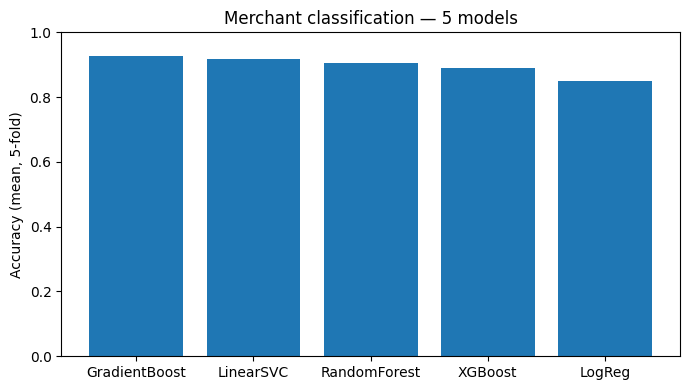

Saved figure -> C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\eda\merchant_models_cv_accuracy.png


In [15]:
models = {
    "LogReg": LogisticRegression(max_iter=200, n_jobs=None),
    "LinearSVC": LinearSVC(),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.1, max_depth=6,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective="multi:softprob", eval_metric="mlogloss", random_state=42
    ),
}

scoring = {
    "accuracy":        accuracy_score,
    "precision_macro": lambda yt, yp: precision_score(yt, yp, average="macro", zero_division=0),
    "recall_macro":    lambda yt, yp: recall_score(yt, yp, average="macro", zero_division=0),
    "f1_macro":        lambda yt, yp: f1_score(yt, yp, average="macro", zero_division=0),
}

rows = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    cvs = cross_validate(
        pipe, X, y_enc, cv=cv, n_jobs=-1,
        scoring={
            "accuracy": "accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro",
        }
    )
    rows.append({
        "model": name,
        "accuracy_mean":        float(np.mean(cvs["test_accuracy"])),
        "precision_macro_mean": float(np.mean(cvs["test_precision_macro"])),
        "recall_macro_mean":    float(np.mean(cvs["test_recall_macro"])),
        "f1_macro_mean":        float(np.mean(cvs["test_f1_macro"])),
        "fit_time_s_mean":      float(np.mean(cvs["fit_time"])),
    })
    print(f"{name:>12}  acc={np.mean(cvs['test_accuracy']):.3f}  f1={np.mean(cvs['test_f1_macro']):.3f}")

tbl = pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
display(tbl.style.format({
    "accuracy_mean":"{:.3f}",
    "precision_macro_mean":"{:.3f}",
    "recall_macro_mean":"{:.3f}",
    "f1_macro_mean":"{:.3f}",
    "fit_time_s_mean":"{:.2f}"
}))

# save table
out_csv = OUT_DIR / "merchant_classification_5models.csv"
tbl.to_csv(out_csv, index=False)
print("Saved table ->", out_csv)

# bar chart (accuracy with error bars not stored here; simple comparison on means)
plt.figure(figsize=(7,4))
plt.bar(tbl["model"], tbl["accuracy_mean"])
plt.ylim(0,1.0)
plt.ylabel("Accuracy (mean, 5-fold)")
plt.title("Merchant classification — 5 models")
plt.tight_layout()
fig_path = FIG_DIR / "merchant_models_cv_accuracy.png"
plt.savefig(fig_path, dpi=160)
plt.show()
print("Saved figure ->", fig_path)


Best model by macro-F1: GradientBoost


c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\venv\Lib\s

              precision    recall  f1-score   support

AMZNMKTPLACE      0.750     1.000     0.857         3
        EBAY      0.800     1.000     0.889        12
    MERCHANT      1.000     1.000     1.000         4
         OTE      0.000     0.000     0.000         2
       OTHER      0.961     0.949     0.955       157
         OTT      1.000     1.000     1.000         3
     PREMIER      0.500     0.500     0.500         2
   REDBRIDGE      1.000     1.000     1.000         2
    RIGHTWAY      1.000     0.750     0.857         4
       TESCO      0.000     0.000     0.000         2

    accuracy                          0.927       191
   macro avg      0.701     0.720     0.706       191
weighted avg      0.926     0.927     0.925       191



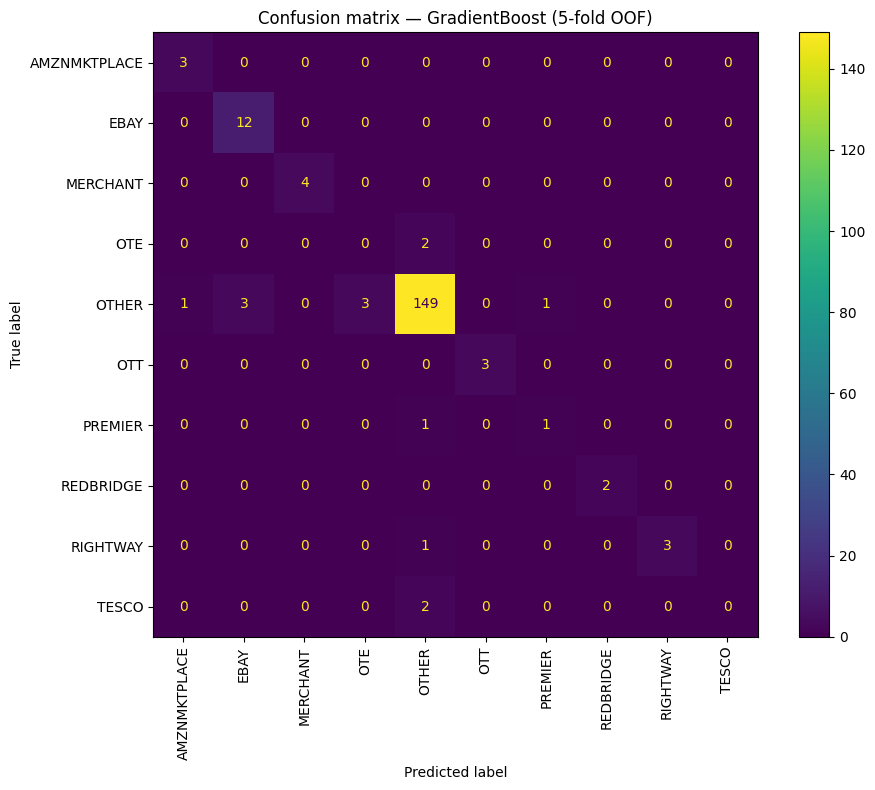

Saved figure -> C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\eda\merchant_confusion_GradientBoost.png


In [16]:
# pick best by macro-F1 (more balanced with class imbalance)
best_name = tbl.loc[0, "model"]
print("Best model by macro-F1:", best_name)

best_pipe = Pipeline([("prep", preprocess), ("clf", models[best_name])])

# OOF predictions with encoded labels
y_pred_enc = cross_val_predict(best_pipe, X, y_enc, cv=cv, n_jobs=-1)

# back to strings for report
y_true = le.inverse_transform(y_enc)
y_pred = le.inverse_transform(y_pred_enc)

print(classification_report(y_true, y_pred, labels=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred, labels=class_names)
fig, ax = plt.subplots(figsize=(10,8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap="viridis", colorbar=True, xticks_rotation=90)
ax.set_title(f"Confusion matrix — {best_name} (5-fold OOF)")
plt.tight_layout()
fig_path = FIG_DIR / f"merchant_confusion_{best_name}.png"
plt.savefig(fig_path, dpi=160)
plt.show()
print("Saved figure ->", fig_path)


In [17]:
from joblib import dump
final_model = best_pipe.fit(X, y_enc)  # fit on full data
model_path = OUT_DIR / f"merchant_classifier_{best_name}.joblib"
dump(final_model, model_path)
print("Saved model ->", model_path)


Saved model -> C:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\models\merchant_classifier_GradientBoost.joblib
